# Experimental cost of in-situ training (referee concern 2, cost)

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg')
from IPython.display import Image, display
RUN = False   # set True to recompute the data of this notebook (cost given in the Compute section)
def show(pdf, dpi=110):
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
ld = lambda n: np.load(os.path.join('data', n), allow_pickle=True)


## Problem
How many repetitions of the experiment does a loss evaluation need, does the squeezing gain survive realistic readout noise, how accurate are finite-difference gradients at a given budget, and can the controls be trained from measured losses?

## Readout model (`expt.py`)
Time-resolved homodyne of the cavity output (rate $\kappa$, efficiency $\eta_c=0.8$) and of the emitter fluorescence (rate $\gamma$, $\eta_e=0.5$). One pass of the sequence with the local oscillators at $(Q,\sigma_x)$ or $(P,\sigma_y)$ yields one estimate of every feature at every virtual time; a loss evaluation costs $2N_{\rm rep}$ passes. Per bin $\tau=T_{\rm in}/N_v$ the detector adds variance $s=1/(\eta\,\text{rate}\,\tau)$:
$$\mathrm{Var}[\hat Q]=\mathrm{Var}(Q)+s_c,\quad \mathrm{Var}[\widehat{Q^2}]=\mathrm{Var}(Q^2)+4\langle Q^2\rangle s_c+2s_c^2,\quad \mathrm{Cov}=\langle Q^3\rangle-\langle Q\rangle\langle Q^2\rangle+2\langle Q\rangle s_c,\quad \mathrm{Var}[\hat\sigma_x]=1-\langle\sigma_x\rangle^2+s_e.$$
Physical units: $\kappa/2\pi=10$ MHz, $\omega_a=5\kappa$, one pass of 1000 symbols = 6.4 µs.

## Studies
* `rev_calib.py` / `rev_post.py`: realized precision and measured squeezing gain vs $N_{\rm rep}$.
* `rev_grad.py`: gradient error and sign recovery vs step $h$ and $N_{\rm rep}$; $h^\star=(3\sigma_{\mathcal L}/|\mathcal L^{(3)}|)^{1/3}$.
* `rev_train.py`: finite-difference gradient descent and SPSA on measured losses, 48 evaluations, from the tuned base with squeezers off.

## Compute (≈ 3 min calibration, ≈ 2 min gradients, ≈ 17 min training)

In [2]:
if RUN:
    for s in ('rev_post.py', 'rev_grad.py', 'rev_train.py'): subprocess.run([sys.executable, s], check=True)

## Results

In [3]:
po = ld('rev_post.npz')
for n in ['mg', 'narma', 'lorenz', 'nce', 'laser']:
    rb, rs = po[f'{n}_base'], po[f'{n}_sq']
    print(n.ljust(7), 'sigma_rel(median) at N=1e6: %.3f' % rs[3, 1], '| measured gain:', ' '.join('%.0e:%+.0f%%' % (N, -100 * (1 - rs[i, 8] / rb[i, 8])) for i, N in enumerate(po['NREP'])))

mg      sigma_rel(median) at N=1e6: 0.131 | measured gain: 1e+03:+0% 1e+04:+2% 1e+05:-0% 1e+06:-0% 1e+07:+0% 1e+08:+0%
narma   sigma_rel(median) at N=1e6: 0.102 | measured gain: 1e+03:-5% 1e+04:-10% 1e+05:-11% 1e+06:-16% 1e+07:-27% 1e+08:-29%
lorenz  sigma_rel(median) at N=1e6: 0.024 | measured gain: 1e+03:-0% 1e+04:-1% 1e+05:+2% 1e+06:-6% 1e+07:-12% 1e+08:-18%
nce     sigma_rel(median) at N=1e6: 0.032 | measured gain: 1e+03:+87% 1e+04:+15% 1e+05:-24% 1e+06:-51% 1e+07:-63% 1e+08:-66%
laser   sigma_rel(median) at N=1e6: 0.034 | measured gain: 1e+03:+7% 1e+04:+4% 1e+05:+4% 1e+06:+7% 1e+07:-4% 1e+08:-10%


In [4]:
gr = ld('rev_grad.npz'); print('task', gr['task'])
for an in ('start', 'mid'):
    g = gr[f'{an}_gtrue']; print(an, 'grad', g.round(4), 'sigma_L/L', (gr[f'{an}_sigL'] / gr[f'{an}_L0']).round(4), "L3", gr[f'{an}_L3'].round(3))
    for b, N in enumerate(gr['NREP']):
        G = gr[f'{an}_G'][:, b]; err = np.sqrt(np.mean(np.sum((G - g) ** 2, -1), -1)) / np.linalg.norm(g)
        print('   N=%.0e  rel. rms error vs h' % N, dict(zip(gr['H'], err.round(2))))

task nce
start grad [-0.1409 -0.0925  0.0004] sigma_L/L [0.0128 0.0075 0.0054] L3 [-6.472  3.986 -0.   ]
   N=1e+05  rel. rms error vs h {np.float64(0.01): np.float64(1.97), np.float64(0.03): np.float64(0.64), np.float64(0.1): np.float64(0.28)}
   N=1e+06  rel. rms error vs h {np.float64(0.01): np.float64(1.14), np.float64(0.03): np.float64(0.42), np.float64(0.1): np.float64(0.21)}
   N=1e+07  rel. rms error vs h {np.float64(0.01): np.float64(0.76), np.float64(0.03): np.float64(0.25), np.float64(0.1): np.float64(0.11)}
mid grad [-0.3122 -0.1749  0.0257] sigma_L/L [0.0201 0.0123 0.0069] L3 [1.088 5.315 0.024]
   N=1e+05  rel. rms error vs h {np.float64(0.01): np.float64(0.77), np.float64(0.03): np.float64(0.36), np.float64(0.1): np.float64(0.42)}
   N=1e+06  rel. rms error vs h {np.float64(0.01): np.float64(0.43), np.float64(0.03): np.float64(0.16), np.float64(0.1): np.float64(0.16)}
   N=1e+07  rel. rms error vs h {np.float64(0.01): np.float64(0.28), np.float64(0.03): np.float64(0.1), 

In [5]:
tr = ld('rev_train.npz'); print('task', tr['task'])
for k in sorted(f for f in tr.files if f.endswith('_Lfinal')): print(k, '%.4e' % float(tr[k]), 'passes %.1e' % float(tr[k.replace('Lfinal', 'passes')]))

task nce
gd_5_0_Lfinal 9.1832e-02 passes 9.6e+06
gd_5_1_Lfinal 1.1831e-01 passes 9.6e+06
gd_6_0_Lfinal 7.4310e-02 passes 9.6e+07
gd_6_0_ni_Lfinal 2.0226e-01 passes 9.6e+07
gd_6_1_Lfinal 2.0264e-01 passes 9.6e+07
gd_6_1_ni_Lfinal 7.5017e-02 passes 9.6e+07
gd_7_0_Lfinal 1.0677e-01 passes 9.6e+08
gd_7_1_Lfinal 7.8578e-02 passes 9.6e+08
spsa_5_0_Lfinal 1.0398e-01 passes 9.6e+06
spsa_5_1_Lfinal 2.0259e-01 passes 9.6e+06
spsa_6_0_Lfinal 1.7947e-01 passes 9.6e+07
spsa_6_0_ni_Lfinal 1.2290e-01 passes 9.6e+07
spsa_6_1_Lfinal 2.0284e-01 passes 9.6e+07
spsa_6_1_ni_Lfinal 9.1597e-02 passes 9.6e+07
spsa_7_0_Lfinal 9.3895e-02 passes 9.6e+08
spsa_7_1_Lfinal 1.0669e-01 passes 9.6e+08


## Noise-aware readout (negative result) and pre-scan training (`rev_snr.py`, `rev_train2.py`)

In [6]:
sn = ld('rev_snr.npz')
for n in ['narma', 'lorenz', 'nce', 'laser']:
    rb, rs = sn[f'{n}_base'], sn[f'{n}_sq']
    print(n.ljust(7), 'gain protocol / noise-aware readout vs N:', ' '.join('%.0e:%+.0f/%+.0f%%' % (N, -100 * (1 - rs[i, 1] / rb[i, 1]), -100 * (1 - rs[i, 3] / rb[i, 3])) for i, N in enumerate(sn['NREP'])))
print('loss noise (protocol, noise-aware) at the start anchor for N=1e5,1e6,1e7:', sn['sigL_start'][:, :2].round(5))
t2 = ld('rev_train2.npz')
for k in sorted(f for f in t2.files if f.endswith('_Lfinal')): print(k, '%.4e' % float(t2[k]))

narma   gain protocol / noise-aware readout vs N: 1e+03:-6/-5% 1e+04:-9/-6% 1e+05:-9/-9% 1e+06:-17/-15% 1e+07:-27/-27% 1e+08:-30/-30%
lorenz  gain protocol / noise-aware readout vs N: 1e+03:-4/-4% 1e+04:+3/+0% 1e+05:+4/+3% 1e+06:-10/-9% 1e+07:-11/-11% 1e+08:-20/-20%
nce     gain protocol / noise-aware readout vs N: 1e+03:+91/+200% 1e+04:+14/+17% 1e+05:-24/-22% 1e+06:-50/-49% 1e+07:-63/-63% 1e+08:-65/-65%
laser   gain protocol / noise-aware readout vs N: 1e+03:+10/+10% 1e+04:+1/+19% 1e+05:+4/+3% 1e+06:+6/+7% 1e+07:-1/-0% 1e+08:-9/-9%
loss noise (protocol, noise-aware) at the start anchor for N=1e5,1e6,1e7: [[0.00257 0.00216]
 [0.00145 0.0011 ]
 [0.001   0.00123]]
gd_5_0_Lfinal 8.8143e-02
gd_5_1_Lfinal 9.3526e-02
gd_6_0_Lfinal 8.4903e-02
gd_6_0_ni_Lfinal 7.8218e-02
gd_6_1_Lfinal 8.4757e-02
gd_6_1_ni_Lfinal 7.8165e-02
gd_7_0_Lfinal 7.5048e-02
gd_7_1_Lfinal 7.4145e-02
spsa_5_0_Lfinal 9.4062e-02
spsa_5_1_Lfinal 1.9976e-01
spsa_6_0_Lfinal 1.6844e-01
spsa_6_0_ni_Lfinal 9.1910e-02
spsa_6_1_Lfi

## Squeezed input noise at the detector (`rev_lo.py`, `rev_lo_diag.py`)
The reflected squeezed input sets the homodyne white noise: $s_c(\phi)=[\eta_c V_{\rm in}(\phi)+1-\eta_c]/(\eta_c\kappa\tau)$, $V_{\rm in}(\phi)=1+2N-2\,\mathrm{Re}(M^*e^{-2i\phi})$. Does choosing the LO angle lower the cost?

In [7]:
import expt; expt.selftest_lo(); print(open('../paper/lotable.tex').read())

selftest_lo ok; V_min 0.4493289641172217 V_max 2.2255409284924674
\begin{tabular}{lcccccccc}
\toprule
LO angles of the two settings & \multicolumn{2}{c}{NARMA10} & \multicolumn{2}{c}{Lorenz-63} & \multicolumn{2}{c}{channel eq.} & \multicolumn{2}{c}{Santa Fe laser}\\
 & $10^6$ & $10^7$ & $10^6$ & $10^7$ & $10^6$ & $10^7$ & $10^6$ & $10^7$\\
\midrule
$(Q,P)$, vacuum input noise & 17 & 27 & 7 & 15 & 50 & 63 & -7 & 1\\
$(Q,P)$, squeezed input noise & 17 & 27 & 9 & 14 & 50 & 63 & -13 & 1\\
$(X_{\phi_{\rm sq}},X_{\phi_{\rm sq}+\pi/2})$ & 16 & 27 & 12 & 14 & 50 & 62 & -16 & -31\\
$(X_{\phi_{\rm sq}},X_{\phi_{\rm sq}})$ & -9 & -6 & 8 & 20 & 49 & 62 & -24 & -48\\
\midrule
$V_{\rm in}$ at $(Q,\ P,\ \phi_{\rm sq},\ \phi_{\rm sq}+\pi/2)$ & \multicolumn{2}{c}{2.44, 0.63, 0.37, 2.70} & \multicolumn{2}{c}{1.45, 0.77, 0.63, 1.60} & \multicolumn{2}{c}{1.61, 1.48, 0.37, 2.72} & \multicolumn{2}{c}{0.70, 1.76, 0.51, 1.94}\\
\bottomrule
\end{tabular}


In [8]:
dg = ld('rev_lo_diag.npz')
for n in ['narma', 'lorenz', 'nce', 'laser']:
    r = dg[f'{n}_QP']; L0 = dg[f'{n}_QP_L0']; i = list(dg['NN']).index(1e6)
    print(n.ljust(7), 'V_in(Q,P,sq,anti)', dg[f'{n}_V'].round(2), '| L/L0 at 1e6: all noise %.2f, emitter noiseless %.2f' % (r[i, 1] / L0[0], r[i, 2] / L0[0]))

narma   V_in(Q,P,sq,anti) [2.44 0.63 0.37 2.7 ] | L/L0 at 1e6: all noise 1.20, emitter noiseless 1.06
lorenz  V_in(Q,P,sq,anti) [1.45 0.77 0.63 1.6 ] | L/L0 at 1e6: all noise 27.18, emitter noiseless 3.63
nce     V_in(Q,P,sq,anti) [1.61 1.48 0.37 2.72] | L/L0 at 1e6: all noise 1.49, emitter noiseless 1.03
laser   V_in(Q,P,sq,anti) [0.7  1.76 0.51 1.94] | L/L0 at 1e6: all noise 1.87, emitter noiseless 1.50


Conclusion: squeezed detection does not lower the cost here: the squeezing axis is not aligned with the informative quadratures, a single squeezed quadrature discards information, and the emitter channel dominates the noise.

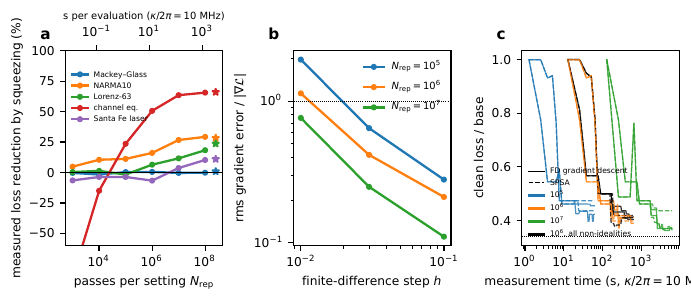

In [9]:
subprocess.run([sys.executable, 'make_rev.py'], check=True, capture_output=True); show('../paper/figs/fig_cost.pdf')

## Interpretation
* The original "$10^4$ shots for 1 % precision" was wrong by two to three orders of magnitude: the detector noise per bin dwarfs the input-driven feature variation.
* Squeezing gains are measurable only above a task-dependent budget ($10^5$–$10^6$ passes per setting for channel equalization, more for Lorenz and the laser).
* The loss noise has a floor from standardizing noise-dominated features; weighting features by measured SNR would remove it.
* Training from measured losses reaches 60–95 % of the noiseless gain in most runs (minutes to an hour of measurement per run at $\kappa/2\pi=10$ MHz), but some runs stall near the starting corner; restarts or a coarse pre-scan are needed.